# 02 - Modeling & Explainability: UNSW-NB15

Trains Random Forest, SVM, MLP, and XGBoost on the binary attack-detection
task, compares them, then explains the best model's predictions using
SHAP (global) and LIME (per-instance).

Run `01_EDA.ipynb` first if you haven't, to understand the data.
Falls back to synthetic sample data automatically if the real dataset
isn't in `data/raw/` yet.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_preprocessing import run_full_preprocessing
from train_models import get_models, evaluate_model
import joblib
import time


In [2]:
X_train, X_test, y_train, y_test, meta = run_full_preprocessing(task='binary')
print(f"Data source: {meta['source']}")
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
X_train.head()


Loading REAL dataset from d:\projects\nids_project\data\raw\UNSW_NB15_training-set.csv
Data source: real
Train: (175341, 42)  Test: (82332, 42)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,-0.191029,0.151816,-0.770468,-0.409206,-0.104456,-0.135769,-0.049134,-0.102726,-0.576371,0.703839,...,-0.645013,-0.544736,-0.554373,-0.705529,-0.118590,-0.118590,-0.189768,-0.715714,-0.753074,-0.126508
1,-0.109485,0.151816,-0.770468,-0.409206,-0.046014,0.172599,-0.046410,0.188544,-0.576345,-1.141901,...,-0.645013,-0.544736,-0.554373,-0.614256,-0.118590,-0.118590,-0.189768,-0.715714,-0.288257,-0.126508
2,0.040699,0.151816,-0.770468,-0.409206,-0.089845,-0.026933,-0.048527,-0.012133,-0.576734,-1.141901,...,-0.520827,-0.544736,-0.554373,-0.522983,-0.118590,-0.118590,-0.189768,-0.595543,-0.288257,-0.126508
3,0.049729,0.151816,0.709875,-0.409206,-0.060624,-0.063212,-0.047016,-0.098563,-0.576737,-1.141901,...,-0.520827,-0.544736,-0.554373,-0.522983,7.814915,7.814915,-0.189768,-0.595543,-0.753074,-0.126508
4,-0.140417,0.151816,-0.770468,-0.409206,-0.075235,-0.117630,-0.047554,-0.102057,-0.576617,0.723268,...,-0.520827,-0.420468,-0.554373,2.854115,-0.118590,-0.118590,-0.189768,-0.595543,2.779535,-0.126508


## Train and compare models

In [3]:
models = get_models()
results = {}
trained_models = {}

for name, model in models.items():
    start = time.time()
    if name == "svm" and len(X_train) > 20000:
        X_train_fit = X_train.sample(20000, random_state=42)
        y_train_fit = y_train.loc[X_train_fit.index]
        print(f"  (SVM subsampled to {len(X_train_fit)} rows for tractable training time)")
    else:
        X_train_fit, y_train_fit = X_train, y_train
    model.fit(X_train_fit, y_train_fit)
    elapsed = time.time() - start
    metrics, report = evaluate_model(name, model, X_test, y_test)
    metrics['train_time_sec'] = round(elapsed, 2)
    results[name] = metrics
    trained_models[name] = model
    print(f"{name:15s} acc={metrics['accuracy']:.3f}  f1={metrics['f1']:.3f}  "
          f"roc_auc={metrics.get('roc_auc', float('nan')):.3f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df.round(4)

random_forest   acc=0.870  f1=0.893  roc_auc=0.982  (11.1s)
  (SVM subsampled to 20000 rows for tractable training time)


d:\projects\nids_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm             acc=0.813  f1=0.854  roc_auc=0.945  (46.7s)
mlp             acc=0.863  f1=0.886  roc_auc=0.970  (420.9s)
xgboost         acc=0.871  f1=0.893  roc_auc=0.982  (4.3s)


,accuracy,precision,recall,f1,roc_auc,train_time_sec
xgboost,0.8708,0.8210,0.9788,0.8930,0.9820,4.33
random_forest,0.8695,0.8152,0.9868,0.8928,0.9816,11.08
mlp,0.8627,0.8144,0.9722,0.8863,0.9699,420.94
svm,0.8134,0.7486,0.9953,0.8545,0.9449,46.68


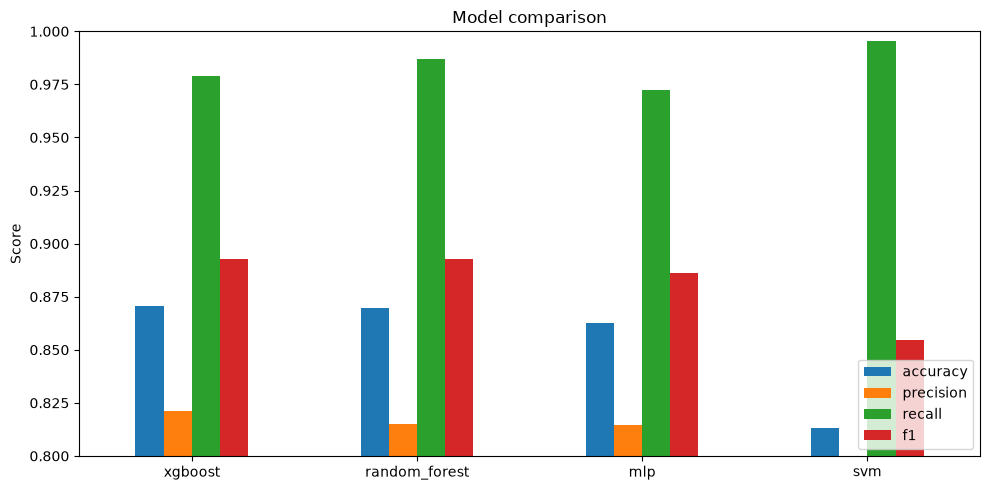

In [4]:
results_df[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(10, 5), ylim=(0.8, 1.0)
)
plt.title('Model comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** compare not just accuracy but precision/recall trade-offs -- in intrusion detection, missing an attack (false negative, hurts recall) is usually worse than a false alarm (false positive, hurts precision). Pick your 'best' model with that asymmetry in mind, not just highest accuracy.

## Explainability: SHAP (global feature importance)

In [5]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Explaining best model: {best_model_name}")


Explaining best model: xgboost


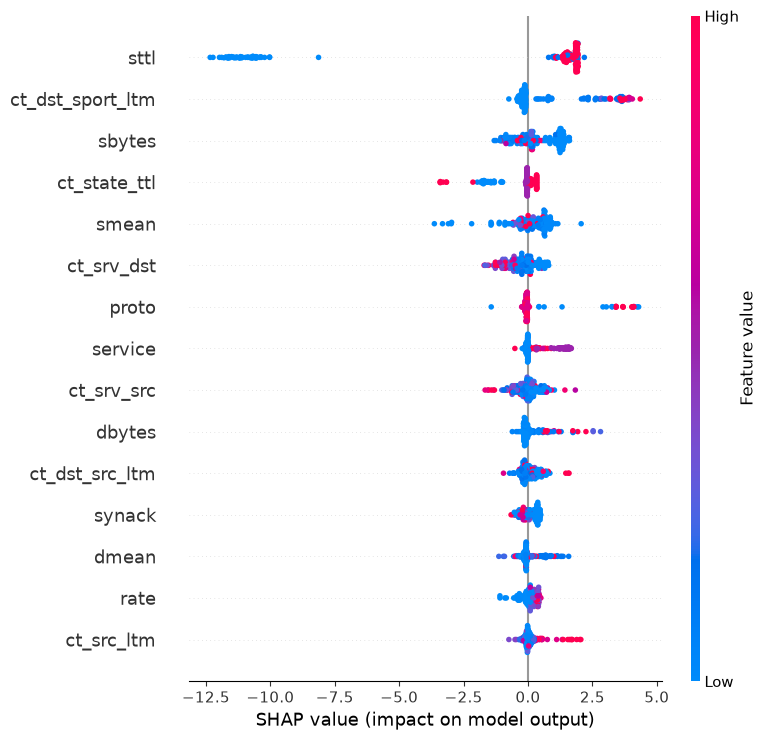

In [6]:
import shap

X_sample = X_test.sample(min(200, len(X_test)), random_state=42)

try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
except Exception as e:
    print(f"TreeExplainer not applicable ({e}), using KernelExplainer (slower)...")
    background = shap.sample(X_train, 50, random_state=42)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_sample, nsamples=100)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

shap.summary_plot(shap_values, X_sample, max_display=15)


**Interpretation:** this beeswarm plot shows, for each feature, how its value (color: red=high, blue=low) pushes the prediction toward 'attack' (right) or 'normal' (left). Features at the top have the biggest overall impact. Use this plot directly in your report to justify which features matter most for detection -- e.g. TTL-related and connection-state features are commonly influential in UNSW-NB15.

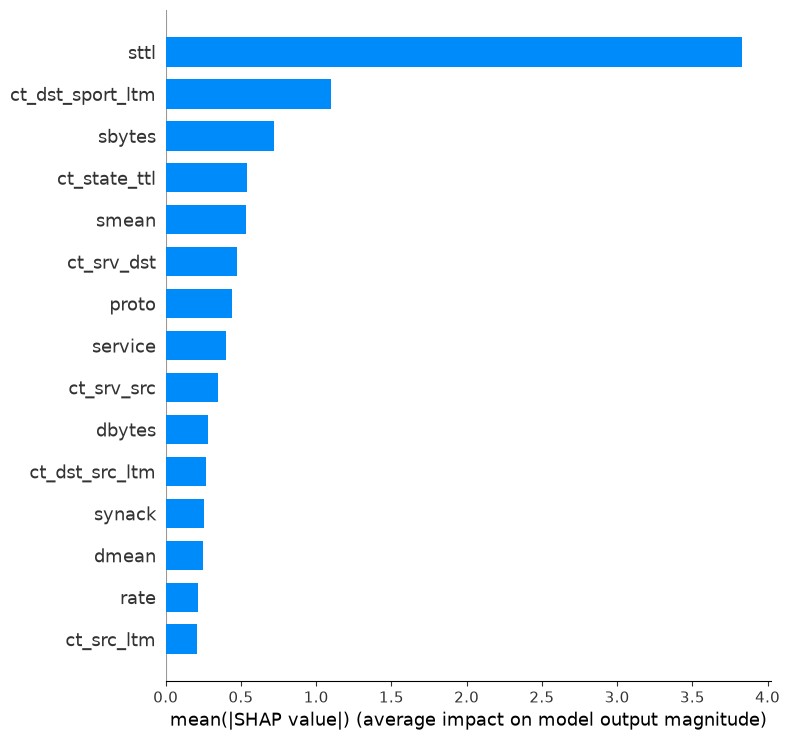

In [7]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15)


## Explainability: LIME (explain one specific prediction)

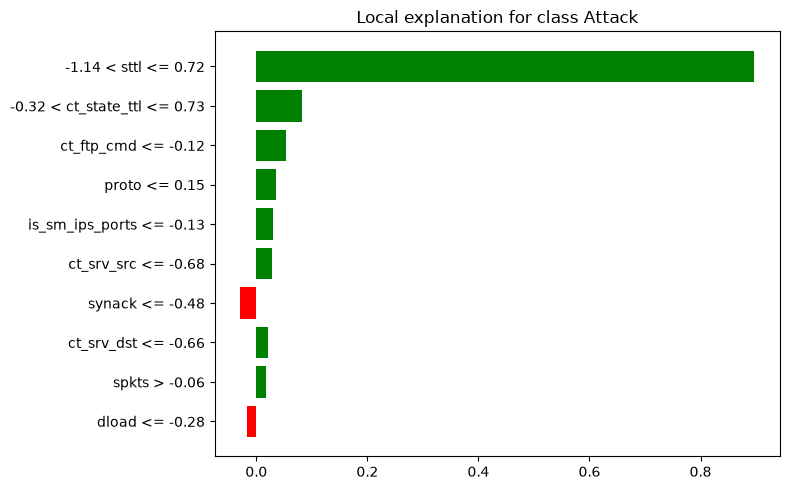

Feature contributions (feature condition, weight toward 'Attack' class):
  -1.14 < sttl <= 0.72                     +0.8968
  -0.32 < ct_state_ttl <= 0.73             +0.0828
  ct_ftp_cmd <= -0.12                      +0.0533
  proto <= 0.15                            +0.0350
  is_sm_ips_ports <= -0.13                 +0.0303
  ct_srv_src <= -0.68                      +0.0286
  synack <= -0.48                          -0.0286
  ct_srv_dst <= -0.66                      +0.0205
  spkts > -0.06                            +0.0170
  dload <= -0.28                           -0.0161


In [8]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['Normal', 'Attack'],
    mode='classification',
    random_state=42,
)

# Pick one flow that was actually an attack, and explain why the model flagged it
attack_idx = int(np.where(y_test.values == 1)[0][0])
instance = X_test.iloc[attack_idx].values

exp = lime_explainer.explain_instance(instance, best_model.predict_proba, num_features=10)

fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

print("Feature contributions (feature condition, weight toward 'Attack' class):")
for feature, weight in exp.as_list():
    print(f"  {feature:40s} {weight:+.4f}")


**Interpretation:** unlike SHAP's global view, this explains ONE specific flow -- useful for a viva demo: 'here is a real attack flow, and here is exactly why the model flagged it.' Pick 2-3 representative examples (one of each major attack category if possible) for your report/presentation.

## Next steps

- Save the best model and use `src/cross_dataset_validation.py` to test generalization
  on CIC-IDS2017 (see README.md for setup).
- For the report: include the model comparison table, SHAP summary plot, and 2-3
  LIME instance explanations as your core "Results & Discussion" figures.


In [9]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, f'../models/{best_model_name}_binary_notebook.pkl')
print(f"Saved best model ({best_model_name}) from notebook run.")

Saved best model (xgboost) from notebook run.
